In [1]:
%matplotlib inline
%load_ext autoreload
import sys

sys.path.append("../")
sys.path.append("/app")

from verimon.analysis import *

experiment_dir = (
    "../stats/exp-2025-04-15_15-00-29-comp-base-prem_sam-premise-snl-snl_sam"
)
experiment_data = load_experiment_data(experiment_dir)

experiment_data = [d for d in experiment_data if "sampling" in d or "verimon" in d]

add_learning_rounds(experiment_data)

experiment_data = combine_sampling_and_verimon(
    experiment_data,
    [
        "file",
        "parameters",
        "horizon",
        "use_random_eq",
        "verimon_walks_per_state",
        "old_walks_per_state",
    ],
)
symbols, colors = add_symbol_color(experiment_data, color_map=None)

clean_data(experiment_data)

add_short_names(experiment_data)


experiments_in_legends = False
save_figures = True
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"
verimon_data = [d for d in experiment_data if "verimon" in d]

plot_kwargs = {
    "fillstyle": "none",
    "markeredgewidth": 1,
    "markersize": 4,
}

Error in 2025-04-15_15-00-29_airport_(file=airportB-7.nm,parameters={'constants': 'DMAX=4,PMAX=4'},horizon=10,slack=[0, 0]).json: std::bad_alloc
Error in 2025-04-15_15-00-29_airport_(file=airportB-7.nm,parameters={'constants': 'DMAX=5,PMAX=5'},horizon=10,slack=[0, 0]).json: std::bad_alloc
Error in 2025-04-15_15-00-29_airport_(file=airportB-7.nm,parameters={'constants': 'DMAX=5,PMAX=5'},horizon=11,slack=[0, 0]).json: std::bad_alloc
Error in 2025-04-15_15-00-29_airport_(file=airportA-7.nm,parameters={'constants': 'DMAX=5,PMAX=5'},horizon=11,slack=[0, 0]).json: std::bad_alloc
Loaded 237/274/1 (86.18%) JSON files from ../stats/exp-2025-04-15_15-00-29-comp-base-prem_sam-premise-snl-snl_sam


The below code generates Table 3 and Figure 14.

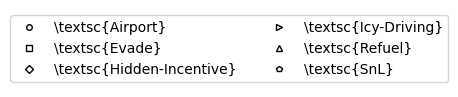

In [2]:
import matplotlib.backend_bases
from matplotlib.backends.backend_pgf import FigureCanvasPgf

matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

name_map = {
    "airport": r"\textsc{Airport}",
    "evade": r"\textsc{Evade}",
    "refuel": r"\textsc{Refuel}",
    "icy-driving": r"\textsc{Icy-Driving}",
    "hidden_incentive": r"\textsc{Hidden-Incentive}",
    "snakes_ladders": r"\textsc{SnL}",
}
legend_elements = {}
for data in verimon_data:
    if data["experiment"]["name"] not in legend_elements:
        legend_elements[data["experiment"]["name"]] = mlines.Line2D(
            [],
            [],
            linewidth=0,
            color=data["color"],
            marker=data["symbol"],
            **plot_kwargs,
            label=f"{name_map[data['experiment']['name']]}",
        )

plt.legend(handles=legend_elements.values(), loc="center", ncol=2)
plt.axis("off")
plt.gcf().set_size_inches(2, 1)
if save_figures:
    plt.savefig(f"{save_path}/legend.pgf", bbox_inches="tight")
plt.show()

generate_learn_table(verimon_data, True, save_path, "experiments")

The below code generates Figures 10 (c,d) and Figure 9

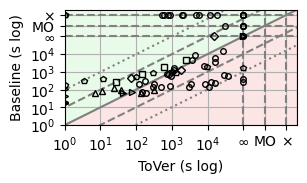

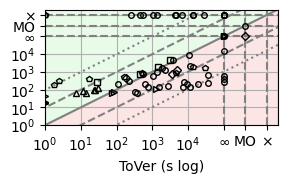

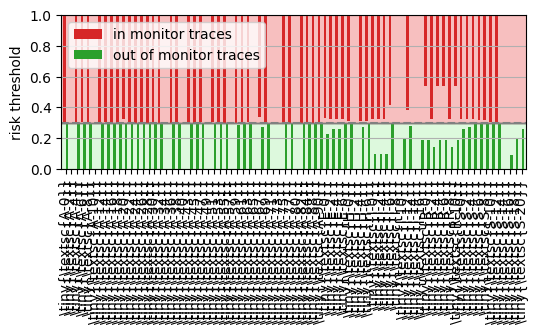

/home/luko/Documents/MDP-product/verimon/analysis.py:1051: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


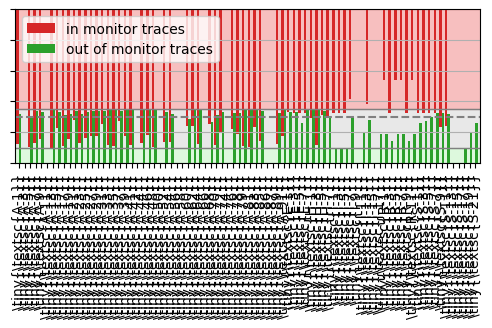

/home/luko/Documents/MDP-product/verimon/analysis.py:1051: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


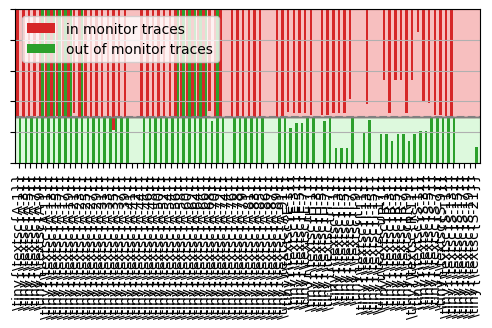

In [3]:
from verimon.analysis import *

verimon_data_with_slack = [
    d for d in verimon_data if float(d["experiment"]["fp_slack"]) > 0
]
verimon_data_no_slack = [
    d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0
]
compare_runtimes(
    verimon_data_with_slack,
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="runtimes_with_slack",
    plot_kwargs=plot_kwargs,
)
compare_runtimes(
    verimon_data_no_slack,
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="runtimes_no_slack",
    show_y_axis=False,
    plot_kwargs=plot_kwargs,
)
# compare_thresholds(verimon_data, "verimon", "sampling", colors)
compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0],
    ["verimon"],
    "name",
    lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
    0.3,
    fig_size=(6, 2),
    # fig_size=(10, 5),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="thresholds_tover_no_slack",
)
compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    ["verimon"],
    "name",
    lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
    0.3,
    0.05,
    0.2,
    fig_size=(6, 2),
    # fig_size=(10, 5),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="thresholds_tover_slack",
    show_y_axis=False,
)

compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    ["sampling"],
    "name",
    lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
    0.3,
    bundle=1,
    fig_size=(6, 2),
    # fig_size=(10, 5),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="theresholds_sampling",
    show_y_axis=False,
)

The below code generates Figures 10 (a,b)

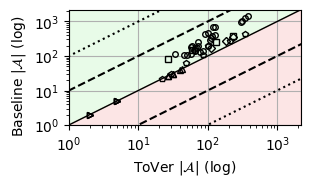

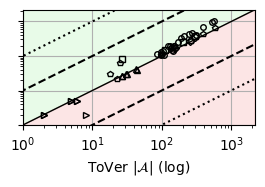

In [4]:
from verimon.analysis import *


compare_monitor_sizes(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="monitor_sizes_with_slack",
    plot_kwargs=plot_kwargs,
)
compare_monitor_sizes(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0],
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="monitor_sizes_no_slack",
    show_y_axis=False,
    plot_kwargs=plot_kwargs,
)

The below code generates figures 12 (a,b,c)

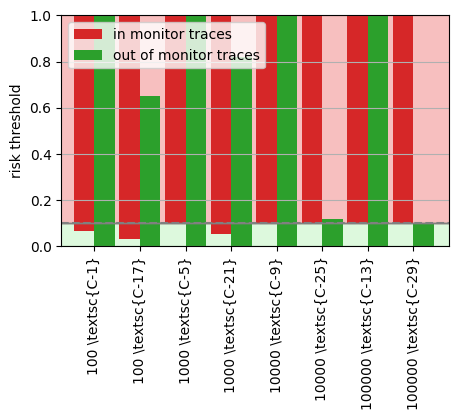

/home/luko/Documents/MDP-product/verimon/analysis.py:1051: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


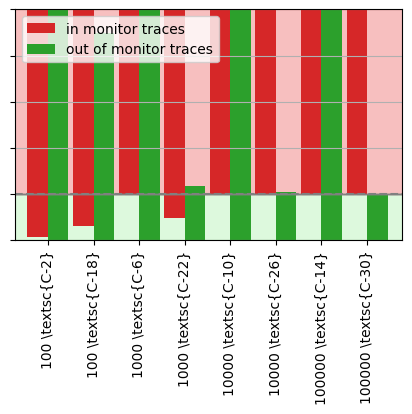

/home/luko/Documents/MDP-product/verimon/analysis.py:1051: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


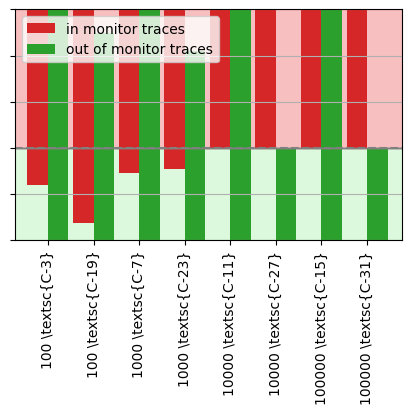

In [5]:
compare_trad_data_low_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.1
            or data["experiment"]["threshold"] == Fraction(1, 10)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_mid_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.2
            or data["experiment"]["threshold"] == Fraction(1, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_high_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.4
            or data["experiment"]["threshold"] == Fraction(2, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)

compare_thresholds_bar(
    compare_trad_data_low_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    threshold=0.1,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_low",
)
compare_thresholds_bar(
    compare_trad_data_mid_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    threshold=0.2,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_mid",
    show_y_axis=False,
)
compare_thresholds_bar(
    compare_trad_data_high_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    threshold=0.4,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_high",
    show_y_axis=False,
)

The below code generates Figure 13.

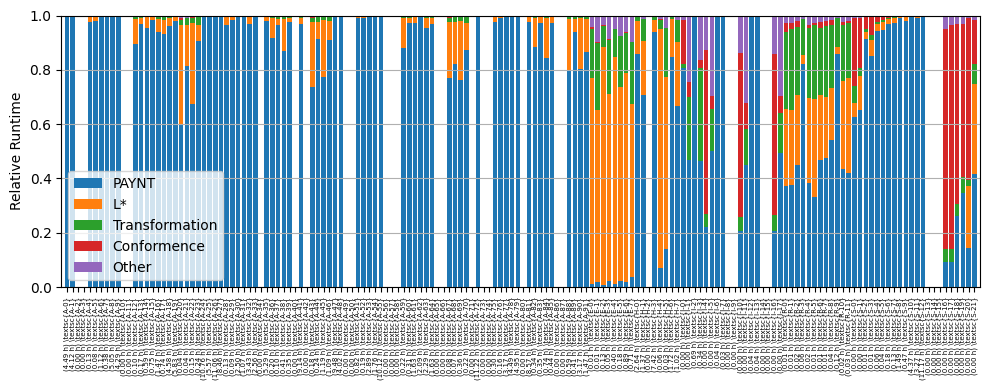

In [6]:
import numpy as np


filtered_data = [
    data for data in experiment_data if data["experiment"]["name"] != "compare-trad"
]
product_times = [
    (
        data["verimon"]["product_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
paynt_times = [
    (
        data["verimon"]["paynt_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
eq_times = [
    (
        data["verimon"]["eq_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
lstar_times = [
    (
        data["verimon"]["lstar_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
other_times = [
    (
        1
        - (
            data["verimon"]["product_time"]
            + data["verimon"]["paynt_time"]
            + data["verimon"]["eq_time"]
            + data["verimon"]["lstar_time"]
        )
        / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]

if experiments_in_legends:
    experiment_names = [
        f"{data['experiment']['name']}\n{data['experiment']['variant']}\n({data['time']['total'] / (60 * 60):.2f} h)"
        for data in filtered_data
    ]
else:
    experiment_names = [
        f"({data['time']['total'] / (60 * 60):.2f} h) {data['experiment']['short_name']}"
        for data in filtered_data
    ]

plt.figure(figsize=(7, 3))
index = range(len(filtered_data))
bottom = np.zeros(len(filtered_data))


plt.bar(index, paynt_times, width=0.8, label="PAYNT")
bottom += paynt_times
plt.bar(index, lstar_times, bottom=bottom, width=0.8, label="L*")
bottom += lstar_times
plt.bar(index, product_times, bottom=bottom, width=0.8, label="Transformation")
bottom += product_times
plt.bar(
    index,
    eq_times,
    bottom=bottom,
    width=0.8,
    label="Conformence",
)
bottom += eq_times
plt.bar(
    index,
    other_times,
    bottom=bottom,
    width=0.8,
    label="Other",
)

plt.ylabel("Relative Runtime")
plt.xticks(index, experiment_names, rotation=90, fontsize=5)
plt.legend(loc="lower left")
plt.xlim(-1, len(filtered_data))
plt.ylim(0, 1)

fig = plt.gcf()
fig.set_size_inches(10, 4)

plt.tight_layout()
plt.grid(axis="y")
if save_figures:
    plt.savefig(f"{save_path}/verimon_times.pgf", bbox_inches="tight")
plt.show()

In [7]:
experiment_dir = "../stats/exp-2025-04-24_12-13-12-verify"
experiment_data = load_experiment_data(experiment_dir)

experiment_data = [
    d for d in experiment_data if not ("sampling" in d or "verimon" in d)
]

symbols, colors = add_symbol_color(experiment_data, verify=True, color_map=None)

clean_data(experiment_data)

add_short_names(experiment_data, verify=True)

add_family_size(experiment_data)

experiments_in_legends = False
save_figures = True
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"

Loaded 516/516/-180 (153.57%) JSON files from ../stats/exp-2025-04-24_12-13-12-verify


The below code generates Table 2.

In [8]:
import matplotlib.backend_bases
from matplotlib.backends.backend_pgf import FigureCanvasPgf

matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

generate_verify_table(
    experiment_data,
    save_figures,
    save_path="../VerifiableMonitorsTex/inprogress/images/plots",
)

The below code generates Figures 11 (a,b).

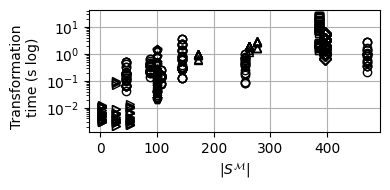

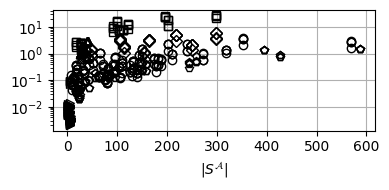

In [9]:
plt.figure(figsize=(4, 2))
plt.grid(True, which="major")
for data in experiment_data:
    plt.plot(
        data["mc"]["mc_states"],
        data["result"]["product_time"],
        color=data["color"],
        marker=data["symbol"],
        fillstyle="none",
        markeredgewidth=1,
    )
plt.yscale("log")
plt.xlabel("$|S^\mathcal{M}|$")
plt.ylabel("Transformation\ntime (s log)", ha="center", y=0.45)
plt.tight_layout()
if save_figures:
    plt.savefig(f"{save_path}/hmm_states_vs_product_runtime.pgf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 2))
plt.grid(True, which="major")
for data in experiment_data:
    plt.plot(
        data["monitor"]["monitor_states"],
        data["result"]["product_time"],
        color=data["color"],
        marker=data["symbol"],
        fillstyle="none",
        markeredgewidth=1,
    )
plt.yscale("log")
plt.xlabel("$|S^\mathcal{A}|$")
# plt.ylabel("Transformation\ntime (s log)", ha="center", y=0.45)
plt.tight_layout()
if save_figures:
    plt.savefig(f"{save_path}/mon_states_vs_product_runtime.pgf", bbox_inches="tight")
plt.show()